In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt
def generate_sequence(seq_length=5,num_samples=1000):
    X,y=[],[]
    for _ in range(num_samples):
        seq=np.random.rand(seq_length)
        X.append(seq)
        y.append(seq[-1]+0.1)
    return np.array(X),np.array(y)

seq_length=5
X,y=generate_sequence(seq_length)
X=X.reshape(X.shape[0],seq_length,1)
split=int(0.8*len(X))
X_train,y_train=X[:split],y[:split]
X_test,y_test=X[split:],y[split:]
model=Sequential([
    SimpleRNN(10,activation='relu',input_shape=(seq_length,1)),
    Dense(1)
])

In [4]:
model.compile(optimizer='adam',loss='mse')
model.summary()
Model: "sequential"

history=model.fit(X_train,y_train,epochs=50,batch_size=16,validation_data=(X_test,y_test))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 5.9869e-05 - val_loss: 1.8375e-05
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4303e-05 - val_loss: 1.4539e-05
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1192e-05 - val_loss: 1.1818e-05
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8114e-06 - val_loss: 1.1657e-05
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.1658e-06 - val_loss: 5.3028e-06
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7613e-06 - val_loss: 3.9145e-06
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3881e-06 - val_loss: 6.0299e-06
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.1903e-06 - val_loss: 5.1671e-06
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.1882e-06 - val_loss: 2.1237e-06
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.7506e-06 - val_loss: 1.9205e-06
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1188e-06

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
Predicted next value: [[0.6000889]]


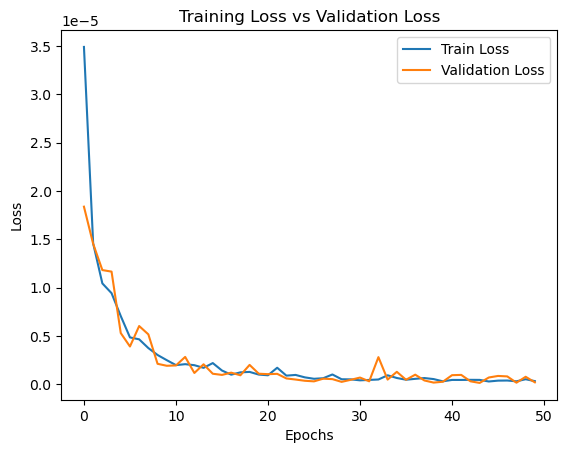

In [5]:
sample_input=np.array([0.1,0.2,0.3,0.4,0.5]).reshape(1,seq_length,1)
predicted_val=model.predict(sample_input)
print(f"Predicted next value: {predicted_val}")

plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')
plt.show()